#3. Visualización de datos Parte 2 
Como ya vimos en la parte 1 de visualización de datos, la visualización es una parte importante a la hora de mostrar los datos. En la parte 2 seguiremos profundizando en la técnica y conoceremos más tipos gráficos.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
nba = pd.read_csv('/content/drive/MyDrive/Mi curso/Data/clean_data/nba_20_per_game.csv')
df = pd.read_csv('/content/drive/MyDrive/Mi curso/Data/clean_data/liga_19_opta.csv')

#3.1. Scatter Plot 
Este es un tipo de gráfico en el que comparamos dos columnas numéricas, en el que se puede ver cómo se relacionan las dos columnas. En el, podemos ver si dos variables están correlacionadas o no, lo que significa que una variable influye sobre la otra. Como por ejemplo, pasa con los tiros a portería y el gol. Es evidente que estas dos variables están correlacionadas, cuanto más tires, más probable será que  marques un gol.  Por tanto, a más tiros, habrá más goles. Esto se le conoce como correlación positiva. Este tipo de correlación se aprecia visualmente por la forma de la nube de puntos del scatter plot. 


## 3.1.1 Matplolib
Para crear un gráfico de dispersión utilizaremos la función plt.scatter() indicando por parámetro que variable irá en cada eje.

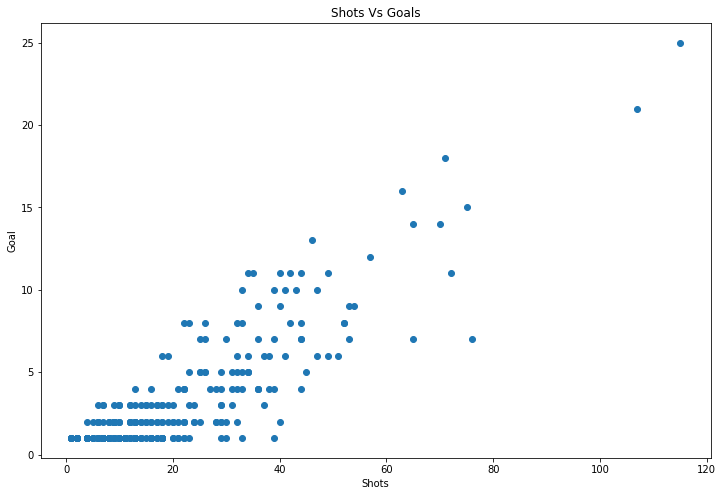

In [3]:
plt.figure(figsize=(12,8))
plt.scatter(df.shots_total, df.goals)
plt.title('Shots Vs Goals')
plt.xlabel('Shots')
plt.ylabel('Goal')
plt.show()

Como vemos, la cantidad de tiros y los goles tienen una correlación positiva, a más tiros más goles. Pero como podemos ver esto no es una relación exacta, como vemos hay jugadores que tiran mucho pero no marcan mucho. Por eso siempre hablamos en términos de probabilidad. Lo más probable es que si un jugador tira mucho marcará más goles. 
 
Este es un tipo de gráfico de los más importantes y que nos permite encontrar relaciones entre variables. Por ejemplo, veamos cómo se relacionan los triples con los triples intentados en la NBA.


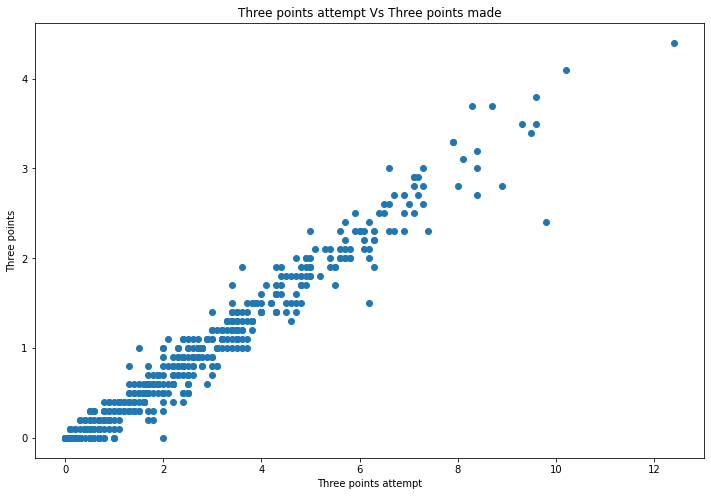

In [5]:
plt.figure(figsize=(12,8))
plt.scatter(nba['3PA'], nba['3P'])
plt.title('Three points attempt Vs Three points made')
plt.xlabel('Three points attempt')
plt.ylabel('Three points')
plt.show()

Si nos fijamos, esta nube de puntos es todavía más estrecha, cuanto más estrecha sea, más fuerte será la correlación entre ambas variables. 
# 3.1.2 Seaborn
Para crear un gráfico de dispersión en seaborn utilizaremos la función sns.scatterplot() 


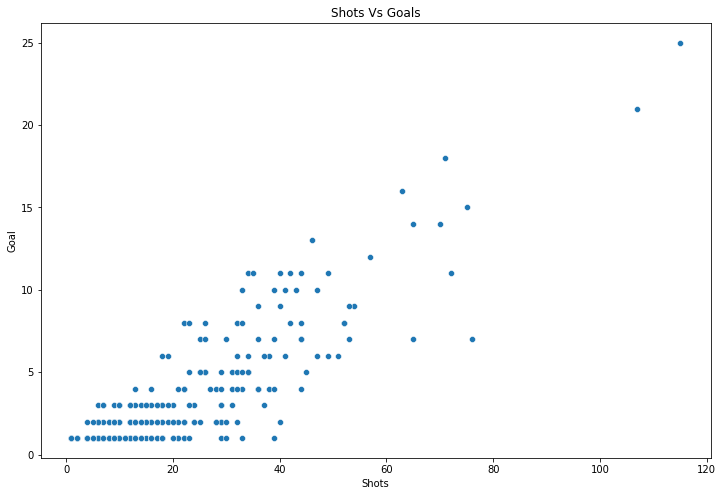

In [6]:
plt.figure(figsize=(12,8))
sns.scatterplot(x=df.shots_total, y=df.goals)
plt.title('Shots Vs Goals')
plt.xlabel('Shots')
plt.ylabel('Goal')
plt.show()

## 3.1.3. Potly
Para crear el scatter plot con plotly utilizaremos el método px.scatter()


In [ ]:
 px.scatter(df[df.position=='Forward'], x='shots_total', y='goals', width=800, title='Shots vs Goals')

# 3.2. Cambiar los estilos al gráfico
Hasta ahora, solo hemos visualizado los gráficos obteniendo siempre el mismo aspecto, aunque es cierto que las diferentes librerías muestran los gráficos de diferente manera. 


## 3.2.1. Cambiar el estilo con sns.set()

Con seaborn tenemos una sencilla manera de cambiar el estilo de los gráficos, para mejorar su estética. Utilizaremos la función sns.set() para este cambio estético. 


In [7]:
sns.set()

Una vez ejecutado, si volvemos a ejecutar las líneas de código del primer gráfico que hicimos con matplotlib, veremos la diferencia. 

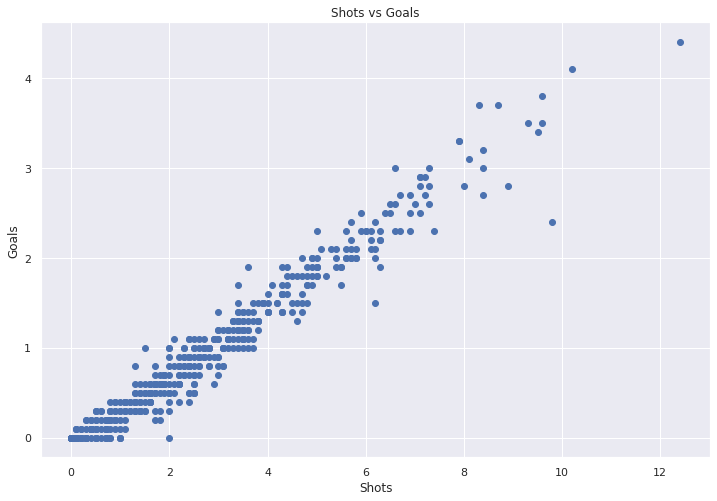

In [ ]:
plt.figure(figsize=(12,8))
plt.scatter(nba['3PA'], nba['3P'])
plt.title('Shots vs Goals')
plt.xlabel('Shots')
plt.ylabel('Goals')
plt.show()

Como vemos la estética del gráfico ha cambiado, ya no tenemos el fondo blanco. Una vez ejecutado sns.set(), todo los gráficos que hagamos a partir de ahora tendrán la estética cambiada. Si quisiéramos tener los gráficos como antes, tendríamos que reiniciar el notebook. Estos cambios sólo se verán reflejados en los gráficos de matplotlib y seaborn. Plotly seguirá teniendo el mismo estilo.
##3.2.2. Cambiar el estilo con sns.set_style()

También tenemos el método sns.set_style() donde por parámetro y entre comillas le podemos indicar los siguientes valores. 

- white
- dark
- whitegrid
- darkgrid
- ticks


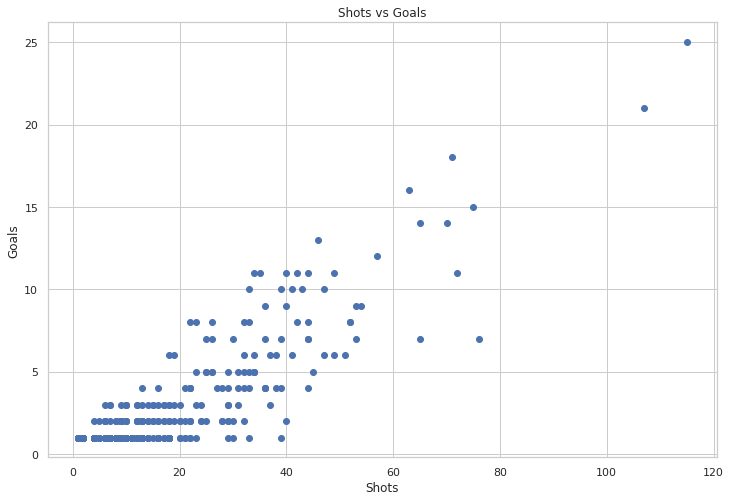

In [9]:
sns.set_style('whitegrid')

plt.figure(figsize=(12,8))
plt.scatter(df.shots_total, df.goals)
plt.title('Shots vs Goals')
plt.xlabel('Shots')
plt.ylabel('Goals')
plt.show()

Recordad que una vez ejecutado sns.set_style(), los gráficos que se realicen a continuación, cambiarán su estilo. 
## 3.2.3. Cambiar el estilo con sns.set_context()

Tenemos otra función con seaborn para cambiar los estilos con sns.set_context(), para la cual tendremos los siguientes valores:

- paper 
- notebook 
- talk 
- poster


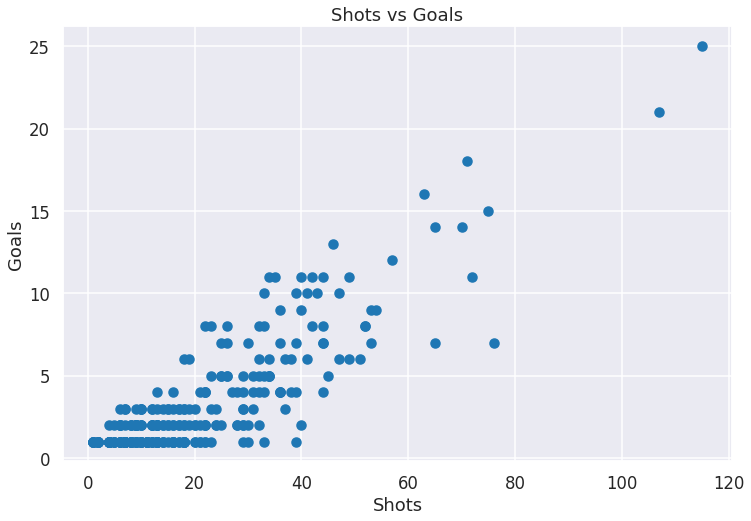

In [ ]:
sns.set_style('darkgrid')
sns.set_context('talk')

plt.figure(figsize=(12,8))
plt.scatter(df.shots_total, df.goals)
plt.title('Shots vs Goals')
plt.xlabel('Shots')
plt.ylabel('Goals')
plt.show()

Como vemos, el gráfico se ha hecho más grande. Yo personalmente siempre suelo utilizar sns.set(), es sencillo y me gusta el toque que le da a los gráficos. 

Este es el pie chart después de ejecutar sns.set()


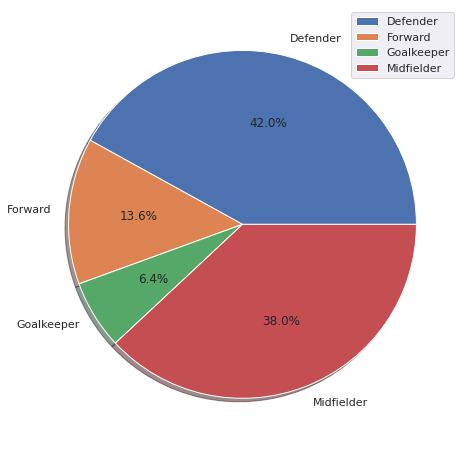

In [11]:
sns.set()
group = df.groupby('position')['passes_total'].sum()

plt.figure(figsize=(12,8))
labels = ['Forward', 'Defender', 'Midfielder', 'Goalkeeper']
plt.pie(x=group.values, labels=group.index, autopct='%1.1f%%', shadow=True)
plt.legend(group.index)
plt.show()

# 3.3. Añadir líneas al gráfico
Una manera de mostrar una mejor información con un scatter plot, es añadir el promedio de cada columna a través de líneas tanto horizontal como vertical. Esto nos permite situar al jugador o equipo por encima o por debajo del promedio. El gráfico se dividirá en cuatro cuadrados y estar en uno de ellos, no estará dando información sobre la fortaleza o debilidad, en función de las variables que estemos graficando. 



## 3.3.1. Añadir líneas con matplotlib
Para añadir las líneas utilizábamos los siguientes métodos de matplotlib.

plt.axvline(): Añadir una línea vertical  
plt.axhline():Añadir una línea horizontal 

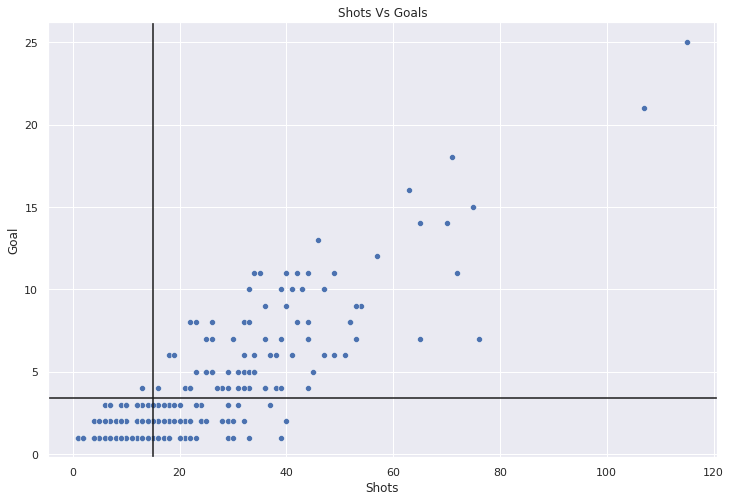

In [12]:
plt.figure(figsize=(12,8))
sns.scatterplot(x='shots_total', y='goals',data=df[df.position != 'Goalkeeper'])
plt.title('Shots Vs Goals')
plt.xlabel('Shots')
plt.ylabel('Goal')
plt.axvline(df.shots_total.mean(), c='k')
plt.axhline(df.goals.mean(), c='k')
plt.show()

Fijaos en la información que estamos viendo ahora. La relación existente entre los tiros a portería y los goles y que jugadores están siendo realmente efectivos en comparación con el resto. 

Los cuatros rectángulos que se nos han formado nos aportan la siguiente  información:

En el primer rectángulo de abajo a la izquierda, tenemos a las jugadoras que tiran poco y marcan poco.
En el segundo rectángulo de abajo a la derecha, tenemos los jugadores que tiran mucho y marcan poco.
En el rectángulo de arriba a la izquierda están los jugadores que tiran poco pero marcan por encima del promedio.
En el rectángulo de arriba a la derecha están los que tiran mucho y marcan mucho.

Vamos a filtrar los datos para solo los delanteros y ver cual de ellos se encuentra por encima o por debajo del promedio de los delanteros. El promedio que calculamos en el gráfico anterior era sobre todos los jugadores menos los porteros.


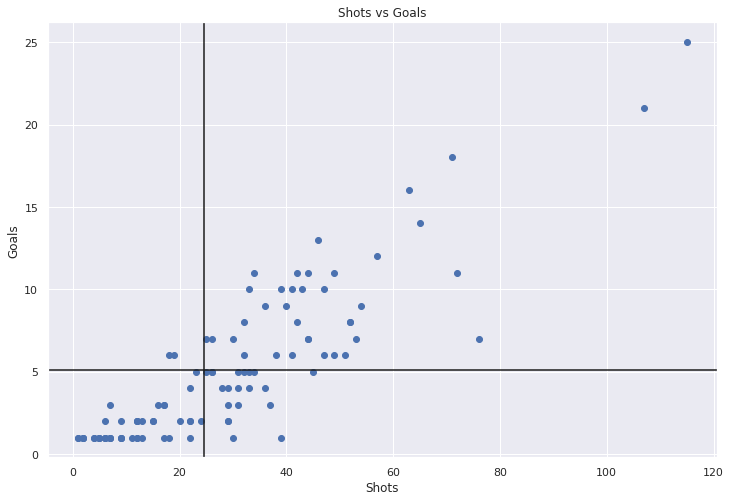

In [13]:
plt.figure(figsize=(12,8))
plt.scatter(data=df[df.position=='Forward'], x='shots_total', y='goals')
plt.title('Shots vs Goals')
plt.xlabel('Shots')
plt.ylabel('Goals')
plt.axvline(df[df.position=='Forward'].shots_total.mean(), c='k')
plt.axhline(df[df.position=='Forward'].goals.mean(), c='k')
plt.show()

Ahora estamos evaluando únicamente al delantero con los promedios de los delanteros. Si nos fijamos, tenemos a dos jugadores en el rectángulo de arriba a la izquierda, donde tiran menos que el promedio pero marcan más que el promedio. Lo que es un muy buen resultado y los convierte en delanteros muy efectivos. 

Añadiendo las líneas horizontales y verticales con los promedios, estamos añadiendo más información al gráfico y contextualizando la información. Tenemos que entender cómo interpretar la información que nos arroja este tipo de gráfico.Un punto muy a la derecha y arriba significa que tira mucho y marca mucho, pero un punto muy a la derecha y más bajo significa alguien que tira mucho pero marca poco. También un punto a la izquierda pero arriba del gráfico, significa que tira poco pero pero mete muchas. Por eso es importante entender lo que nos está mostrando este gráfico. 
## 3.3.2. Añadir líneas con Plotly
Con plotly tendremos que guardar el gráfico en una variable y aplicar la función .add_shape(), a la variable donde se ha guardado el gráfico.  Primero guardamos el gráfico en la variables fig.


In [ ]:
fig = px.scatter(df[df.position=='Forward'], x='shots_total', y='goals', width=800, title='Shots vs Goals')

Para después hacer las modificaciones con .add_shape(). Donde tendremos que especificar los promedios, más  los máximos y mínimos que serán los límites de la líneas. 

In [ ]:
fig.add_shape(type='line',
              x0= df[df.position=='Forward'].shots_total.mean(),
              y0=df[df.position=='Forward'].goals.min(),
              y1=df[df.position=='Forward'].goals.max(), 
              x1=df[df.position=='Forward'].shots_total.mean())

fig.add_shape(type='line',
              x0=df[df.position=='Forward'].shots_total.min(),
              y0=df[df.position=='Forward'].goals.mean(),
              x1=df[df.position=='Forward'].shots_total.max(),
              y1=df[df.position=='Forward'].goals.mean())

Como vemos cada librería tiene sus pros y sus contras, por eso os intento enseñar las diferentes librerías, para en función de lo que queráis, elegir una u otra. Con matplotlib es más sencillo añadir las líneas pero con plotly tenemos el gráfico interactivo y podemos saber el valor exacto de cada punto. 

#3.4. Añadir texto al gráfico
Una manera de mejorar el gráfico es añadir el nombre de los jugadores o equipos, para poder ver a quién pertenece cada punto. De nuevo con unas librerías será más sencillo que con otras. 


## 3.4.1. Añadir texto con Plotly
Ya vimos en anteriores ocasiones como añadir texto con plotly a través de su parámetro text y pasándole como valor, la columna que contiene el nombre de los jugadores o equipos. 


In [ ]:
fig = px.scatter(df[df.position=='Forward'], x='shots_total', y='goals', text='player_name' ,width=800, title='Shots vs Goals')

fig.add_shape(type='line',
              x0= df[df.position=='Forward'].shots_total.mean(),
              y0=df[df.position=='Forward'].goals.min(),
              y1=df[df.position=='Forward'].goals.max(), 
              x1=df[df.position=='Forward'].shots_total.mean())

fig.add_shape(type='line',
              x0=df[df.position=='Forward'].shots_total.min(),
              y0=df[df.position=='Forward'].goals.mean(),
              x1=df[df.position=='Forward'].shots_total.max(),
              y1=df[df.position=='Forward'].goals.mean())

Cuando tenemos muchos puntos, es difícil que se pueda ver el nombre de los jugadores ya que se sobrescriben unos encima de otros. 

Para estas ocasiones, tenemos un parámetro que hover_name, veamos qué ocurre, si le pasamos como valor la columna que contiene el nombre de los jugadores.


In [ ]:
fig = px.scatter(df[df.position=='Forward'], x='shots_total', y='goals', hover_name='player_name' ,width=800, title='Shots vs Goals')

fig.add_shape(type='line',
              x0= df[df.position=='Forward'].shots_total.mean(),
              y0=df[df.position=='Forward'].goals.min(),
              y1=df[df.position=='Forward'].goals.max(), 
              x1=df[df.position=='Forward'].shots_total.mean())

fig.add_shape(type='line',
              x0=df[df.position=='Forward'].shots_total.min(),
              y0=df[df.position=='Forward'].goals.mean(),
              x1=df[df.position=='Forward'].shots_total.max(),
              y1=df[df.position=='Forward'].goals.mean())

Vemos como los nombres no aparecen directamente, pero al pasar el ratón por encima de algún punto, podremos saber a qué jugador corresponde dicho punto.
## 3.4.2. Añadir texto con Matplotlib
Hay un método en matplotlib que nos permite añadir texto a los gráficos, en este caso el nombre de los jugadores, este método es  plt.annotate(). Con matplotlib no será tan sencillo añadir el nombre de los jugadores a cada punto del gráfico. 

Necesitaremos pasarle a la función plt.annotate() el nombre de los jugadores y las coordenadas (x, y) de cada punto. Pero con plt.annotate() no bastará con pasarle las columnas que contienen dichos valores. Necesitaremos pasarle los valores de todos y cada uno de los puntos. Por tanto vamos a necesitar usar un bucle for, que vaya pasando por todo los valores y se los vaya pasando a la función plt.annotate(), donde tendremos los siguientes parámetros:

- s: Donde le pasaremos el nombre del jugador.
- xy: Le indicamos el valor de las columnas que van en dichos ejes.
- ha: Donde se colocara el nombre respecto del punto. 

Por tanto tenemos que realizar un bucle for, que vaya añadiendo punto a punto  su respectivo nombre. Veamos un ejemplo de lo que hará el bucle for, de los valores que le pasaremos  a la función plt.annotate() en cada iteración


In [14]:
for i in range(len(df)):
  print(df.player_name.values[i], df.shots_total.values[i], df.goals.values[i])

Mauro Arambarri 33.0 1.0
Markel Bergara nan nan
Erick Cabaco 3.0 nan
Leandro Cabrera 9.0 2.0
Marc Cucurella 21.0 1.0
Djené Dakonam 5.0 nan
Hugo Duro 5.0 1.0
Oghenekaro Etebo 8.0 1.0
Xabier Etxeita 4.0 nan
Faycal Fajr 7.0 nan
Enrique Gallego Puigsech 17.0 3.0
Raúl García 5.0 nan
Bruno González 1.0 nan
Nemanja Maksimovic 28.0 2.0
Jaime Mata 49.0 11.0
Jorge Molina 25.0 5.0
Amath Ndiaye nan nan
Robert Kenedy Nunes do Nascimento 8.0 1.0
Allan-Roméo Nyom 9.0 2.0
Mathías Olivera 5.0 nan
Vitorino Gabriel Pacheco Antunes nan nan
Francisco Portillo 2.0 nan
Florent Poulolo nan nan
David Remeseiro Salgueiro 16.0 1.0
José Manuel Rodríguez Benito 2.0 nan
Ángel Rodríguez 43.0 10.0
Deyverson Brum Silva Acosta 4.0 nan
David Soria nan nan
Damián Suárez 13.0 1.0
David Timor 15.0 3.0
Mahmoud Abdallahi nan nan
Martín Aguirregabiria 2.0 1.0
Oliver Burke 16.0 1.0
Víctor Camarasa 7.0 nan
Paulino De la Fuente nan nan
Rubén Duarte 17.0 nan
Rodrigo Ely 6.0 2.0
Ljubomir Fejsa 1.0 nan
Jorge Franco Alviz nan nan
Ma

No he imprimido todos los jugadores por cuestión de espacio, pero como vemos a través de .values y el iterador i, vamos pasando por los diferentes valores de las columnas, sabiendo el nombre de los jugadores y el valor de las coordenadas (x, y). Ahora sustituimos estos valores a la función plt.annotate().

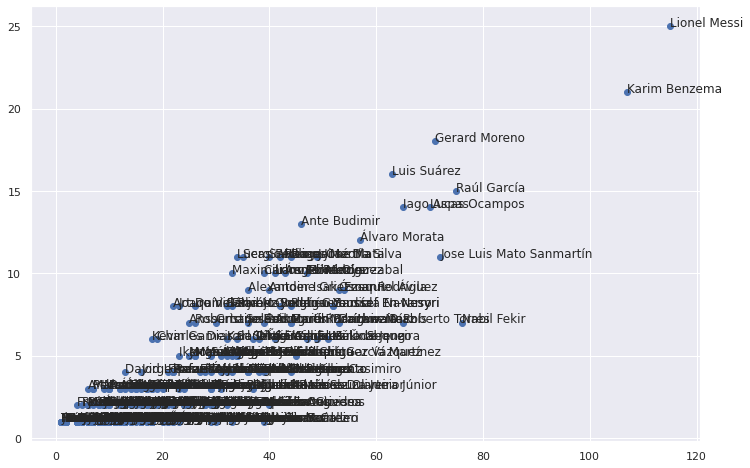

In [15]:
plt.figure(figsize=(12,8))
plt.scatter(data=df, x='shots_total', y='goals')

for i in range(len(df)):
  plt.annotate(s=df.player_name.values[i], xy=(df.shots_total.values[i], df.goals.values[i]), ha='left')

Vemos que el nombre se encuentra justo encima del punto, con los siguientes parámetros podemos alejarlos del punto:

- textcoords: Con el valor ‘offset points’ indicaremos que queremos los nombres fuera del punto.
- xytext: Una vez colocado textcoords deberemos cuanto queremos de alejado el nombre del punto. 


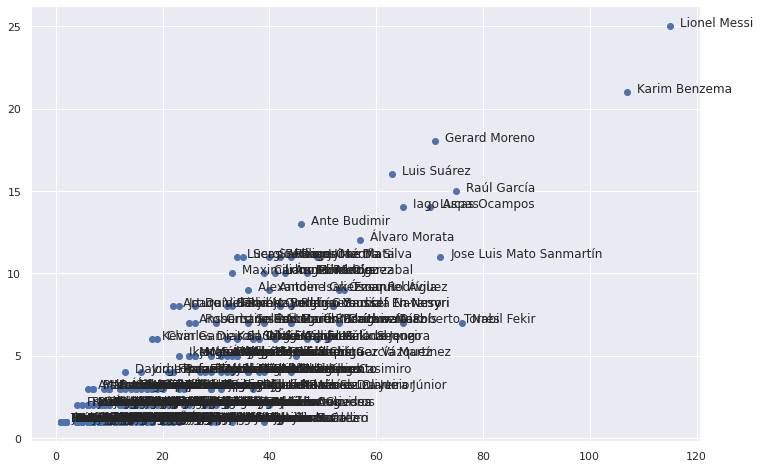

In [16]:
plt.figure(figsize=(12,8))
plt.scatter(data=df, x='shots_total', y='goals')

for i in range(len(df)):
  plt.annotate(s=df.player_name.values[i], xy=(df.shots_total.values[i], 
               df.goals.values[i]), ha='left',textcoords='offset points', xytext=(10,0))

Podemos ver como ahora los nombres no se encuentran justo encima del punto.

Pero seguimos teniendo el problema de cómo los nombres están unos encima de otros. Mi consejo es si queremos mostrar una imagen donde se vean los nombres sea con la librería que sea, deberíamos hacer un filtrado primero. Como por ejemplo crear un top 25 de los jugadores que más tiran. 

In [17]:
top_25 = df[df.position != 'Goalkeeper'].sort_values('shots_total', ascending=False).head(25)

Una vez creado nuestro nuevo dataframe con los 25 jugadores que más tiran, será más sencillo añadir sus nombres al gráfico. 



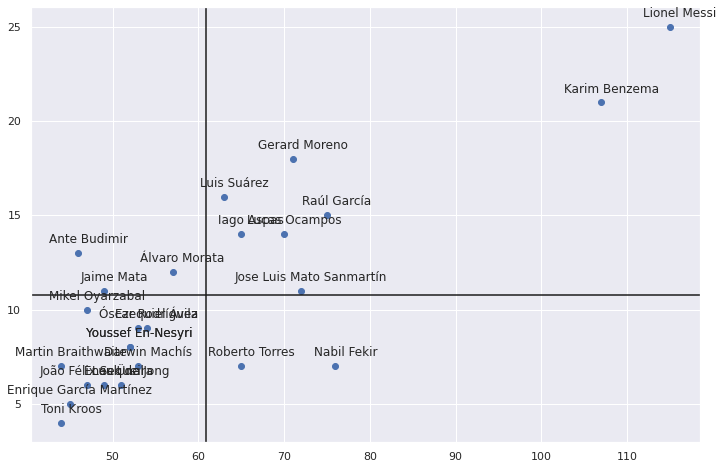

In [18]:
plt.figure(figsize=(12,8))
plt.scatter(data=top_25, x='shots_total', y='goals')

plt.axvline(top_25.shots_total.mean(), c='k')
plt.axhline(top_25.goals.mean(), c='k')

for i in range(len(top_25)):
  plt.annotate(s=top_25.player_name.values[i], xy=(top_25.shots_total.values[i],     
               top_25.goals.values[i]), ha='center',textcoords='offset points', xytext=(10,10))

Ahora tenemos un gráfico con los jugadores que más tiran con sus respectivos nombres. Todavía hay alguna que se sobreescribe pero el gráfico ya tiene mucho mejor aspecto. 
#3.5. Añadir color
Añadir color en el gráfico es una manera de poder añadir más información en base a columnas categóricas. Hemos estado viendo esto en la parte 1 de visualización. 


## 3.5.1. Añadir color con seaborn
Ya conocemos el parámetro hue en los gráficos de seaborn, que nos permite añadir color en función de una columna categórica.

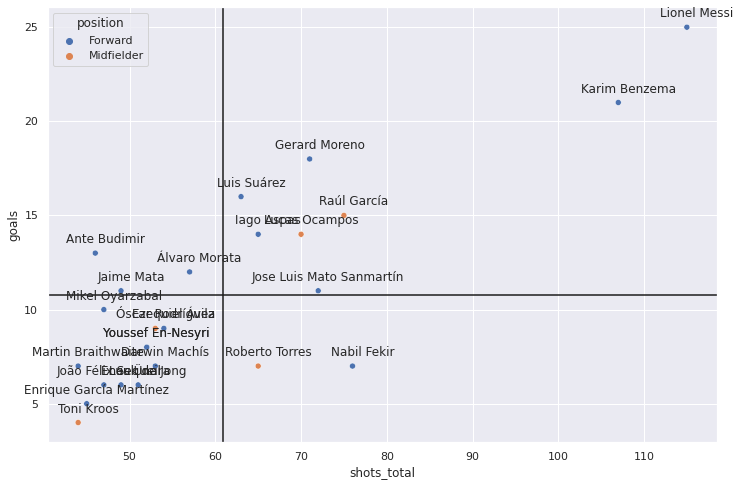

In [19]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=top_25, x='shots_total', y='goals', hue='position')

plt.axvline(top_25.shots_total.mean(), c='k')
plt.axhline(top_25.goals.mean(), c='k')

for i in range(len(top_25)):
  plt.annotate(s=top_25.player_name.values[i], xy=(top_25.shots_total.values[i],      
               top_25.goals.values[i]), ha='center',textcoords='offset points', xytext=(10,10))

Podemos ver como de los 25 jugadores que más tiran, solo hay delanteros y mediocentros. Siendo el cuarto jugador que más tira un mediocentro.

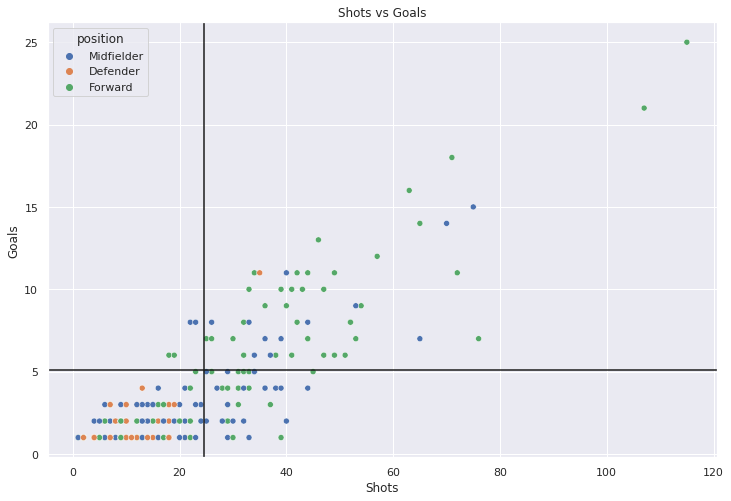

In [ ]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=df[df.position != 'Goalkeeper'], x='shots_total', y='goals', hue='position')
plt.title('Shots vs Goals')
plt.xlabel('Shots')
plt.ylabel('Goals')
plt.axvline(df[df.position=='Forward'].shots_total.mean(), c='k')
plt.axhline(df[df.position=='Forward'].goals.mean(), c='k')
plt.show()

Gracias a añadir el color podemos ver de una manera sencilla que hay un defensa que mete  muchos goles, siendo el único defensa que tira y marca por encima del promedio. 
## 3.5.1. Añadir color con plotly
Con plotly,  añadimos color al gráfico en función de una columna categórica,  con el parámetro color. Añadiremos también hover_name par saber quien es ese defensa que marca tanto. 


In [20]:
fig = px.scatter(df[df.position != 'Goalkeeper'], x='shots_total', y='goals', hover_name='player_name' ,width=800, title='Shots vs Goals', color = 'position', )

fig.add_shape(type='line',
              x0= df[df.position!= 'Goalkeeper'].shots_total.mean(),
              y0=df[df.position!= 'Goalkeeper'].goals.min(),
              y1=df[df.position!= 'Goalkeeper'].goals.max(), 
              x1=df[df.position!= 'Goalkeeper'].shots_total.mean())

fig.add_shape(type='line',
              x0=df[df.position!= 'Goalkeeper'].shots_total.min(),
              y0=df[df.position!= 'Goalkeeper'].goals.mean(),
              x1=df[df.position!= 'Goalkeeper'].shots_total.max(),
              y1=df[df.position!= 'Goalkeeper'].goals.mean())

# 3.5. Mapas de calor
Antes de graficar un mapa de calor tenemos que entender lo que es una matriz de correlación. Al principio del todo, ya vimos como el scatter plot era un gráfico que nos mostraba la correlación entre dos variables. Además de observar esta correlación de manera visual, la podemos cuantificar con la función .corr(). 

Si añadimos .corr() a un dataframe, obtendremos una matriz donde las filas y las columnas son las columnas del dataframe y obtendremos el valor de correlación que hay entre ellas. Los valores irán desde (-1, 1 ). Los valores cerca de 1 o -1 significa una correlación fuerte y siendo el valor de cero o cercanos a 0 una correlación débil. Que sea negativa o positiva, solo indica el tipo de relación entre ellas. Positiva, es que a medida que aumente la x, aumenta también la y. Una correlación negativa, significa que al aumentar x disminuye la y. Sigue habiendo correlación pero negativa. 

In [21]:
nba.corr()

,Age,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
Age,1.000000,0.152830,0.114611,0.169431,0.096497,0.111507,-0.002183,0.201598,0.191409,0.132387,0.026745,0.031082,0.009591,0.080579,0.073261,0.052537,0.077553,0.018820,0.136828,0.107923,0.170693,0.095520,0.034694,0.091384,0.090246,0.112089
G,0.152830,1.000000,0.612051,0.682715,0.547689,0.533966,0.260320,0.472797,0.446546,0.356075,0.458471,0.459154,0.215989,0.364717,0.400062,0.405215,0.402718,0.293681,0.491733,0.460312,0.410609,0.483083,0.303769,0.441685,0.482328,0.543548
GS,0.114611,0.612051,1.000000,0.799004,0.733611,0.722329,0.180655,0.522774,0.517385,0.219379,0.664763,0.678015,0.125491,0.216226,0.604151,0.609478,0.250968,0.389593,0.652095,0.609760,0.568392,0.576293,0.368177,0.646521,0.579246,0.727418
MP,0.169431,0.682715,0.799004,1.000000,0.880782,0.887415,0.207642,0.684985,0.689877,0.329271,0.772133,0.797611,0.153273,0.292075,0.713237,0.715125,0.409600,0.415358,0.734493,0.679523,0.692549,0.727639,0.394974,0.781725,0.738384,0.878537
FG,0.096497,0.547689,0.733611,0.880782,1.000000,0.976443,0.274179,0.652531,0.654092,0.289665,0.935738,0.946036,0.189155,0.303727,0.847665,0.851615,0.335115,0.431439,0.727160,0.678952,0.715053,0.624140,0.392662,0.856413,0.621682,0.988496
FGA,0.111507,0.533966,0.722329,0.887415,0.976443,1.000000,0.123697,0.745602,0.765027,0.317797,0.863153,0.906332,0.073475,0.187758,0.841668,0.830172,0.360354,0.300476,0.656214,0.586084,0.747231,0.639500,0.296104,0.863695,0.578700,0.982947
FG%,-0.002183,0.260320,0.180655,0.207642,0.274179,0.123697,1.000000,-0.084600,-0.156011,0.078582,0.379714,0.276755,0.826881,0.926271,0.165681,0.212397,0.127506,0.511039,0.348159,0.416415,0.057778,0.078177,0.405701,0.157179,0.350845,0.221703
3P,0.201598,0.472797,0.522774,0.684985,0.652531,0.745602,-0.084600,1.000000,0.979101,0.498606,0.343968,0.407747,-0.049856,0.168714,0.531209,0.473459,0.383421,-0.142056,0.300114,0.184846,0.530212,0.451414,-0.000532,0.547832,0.352757,0.717631
3PA,0.191409,0.446546,0.517385,0.689877,0.654092,0.765027,-0.156011,0.979101,1.000000,0.432266,0.354902,0.421380,-0.063507,0.078447,0.558290,0.501319,0.369610,-0.151712,0.307084,0.187096,0.558605,0.469709,-0.002845,0.579800,0.353810,0.721927
3P%,0.132387,0.356075,0.219379,0.329271,0.289665,0.317797,0.078582,0.498606,0.432266,1.000000,0.126908,0.164544,-0.033564,0.329458,0.163715,0.132117,0.334851,-0.123565,0.111183,0.048042,0.228430,0.213300,-0.008234,0.198556,0.161816,0.309870


Como podemos, ver la diagonal de la matriz son todos unos, porque es la comparación de la columna con sigo misma. Este tipo de matriz nos ayuda a saber qué columnas están correlacionadas entre ellas. 

Para estos casos es lo que viene perfecto al función sns.heatmap() ya que podremos ver visualmente estas correlaciones. 

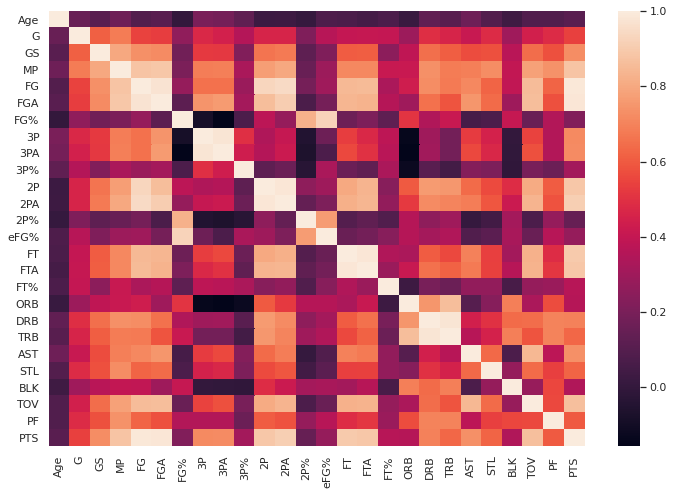

In [22]:
plt.figure(figsize=(12,8))
sns.heatmap(nba.corr())

Ahora vemos de manera visual, que columnas están correlacionadas entre ellas. Con la barra de la derecha sabremos que simboliza cada color. 

Saber la correlación entre variables es importante a al hora de crear algoritmos de inteligencia artificial, ya que para hacer buenas predicciones, necesitamos las x que estén correlacionadas fuertemente con la y para hacer buenas predicciones. 

Con la correlación podemos ayudar a un algoritmo a entender un deporte. Ya hemos visto como el gol, es una característica peculiar del fútbol y que dependiendo de la posición que ocupes en el campo, será más o menos importante. Nosotros esto como humanos lo entendemos, pero cómo hacemos que entienda esto un algoritmo? Pues gracias a la estadística y la matemática podemos hacer entender a un algoritmo, la importancia del gol para depende qué posiciones. 

Vemos la correlación entre los tiros y el gol: 


In [23]:
df[['shots_total', 'goals']].corr()

,shots_total,goals
shots_total,1.00000,0.85998
goals,0.85998,1.00000


Si ahora filtramos los datos por cada posición y calculamos la correlación, veremos cómo cambia para cada posición.

In [24]:
df[df.position == 'Forward'][['shots_total', 'goals']].corr()

,shots_total,goals
shots_total,1.000000,0.879226
goals,0.879226,1.000000


Para los delanteros la correlación acaba de aumentar.

In [25]:
df[df.position == 'Defender'][['shots_total', 'goals']].corr()

,shots_total,goals
shots_total,1.00000,0.52234
goals,0.52234,1.00000


Para los defensas la correlación ha disminuido mucho, haciéndonos entender que el gol no está muy relacionado con ellos.

In [27]:
df[df.position == 'Midfielder'][['shots_total', 'goals']].corr()

,shots_total,goals
shots_total,1.000000,0.776367
goals,0.776367,1.000000


La correlación para los mediocentros es mayor que la de los defensas, pero no es tan fuerte como la de los delanteros. La columna position sería importante para un algoritmo de inteligencia artificial, para la predicción de goles.

# 3.6. Visualizar múltiples gráficos
El parámetro hue, fue quien nos permitió poder mostrar las posiciones en el gráfico a través del color. Ahora veremos una técnica avanzada para poder graficar la comparación de los tiros con los goles, pero con un gráfico para cada posición. 


In [29]:
defender = df[df.position == 'Defender']
fw = df[df.position == 'Forward']
md = df[df.position == 'Midfielder']

Ahora tenemos distintos dataset, uno para cada posición. Por ejemplo en el dataset defensa, solo tendremos datos de los defensas.

Como estamos analizando tres posiciones, defender, forward y midfielder, vamos a crear tres gráficos de dispersión, uno para cada uno. Con plt.subplots(), podemos colocar los gráficos en horizontal o vertical dentro de la imagen. Este es el resultado final de aplicar plt.subplots(), para que veas de qué estoy hablando.


Para conseguir este resultado, solo necesitamos añadir la siguiente línea de código. A continuación te explico su significado.


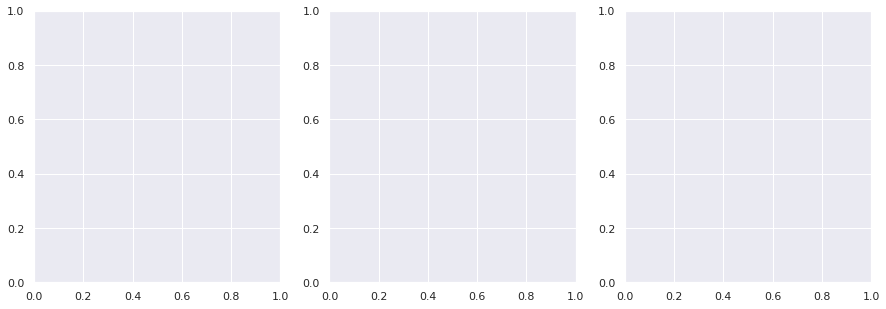

In [30]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15,5))

- nrows: Especificamos el número de filas, en este caso con 1, estás indicando que solo quieres una fila, por tanto los gráficos te saldrán en fila, uno al lado del otro.

- ncols: El número de columnas que añadiremos a la fila, ponemos 3, porque queremos graficar las tres posiciones.

- figsize: Especificamos el tamaño que tendrá la imagen, antes la especificamos con plt.figure(), pero con subplots lo especificamos por parámetro.

El resultado de salida, se guarda en las variables fig y ax. Esto es importante de entender, porque ahora ya no añadiremos el gráfico scatter con plt, si no con la variable ax.

Al utilizar plt.subplots(), añadiremos todos los métodos de plt a la variable ax y para indicar a qué columna añadimos el gráfico, lo haremos a través de corchetes. Recordad siempre, que el índice de la primera columna es 0. Así quedaría el código para el dataset de los defensas. 


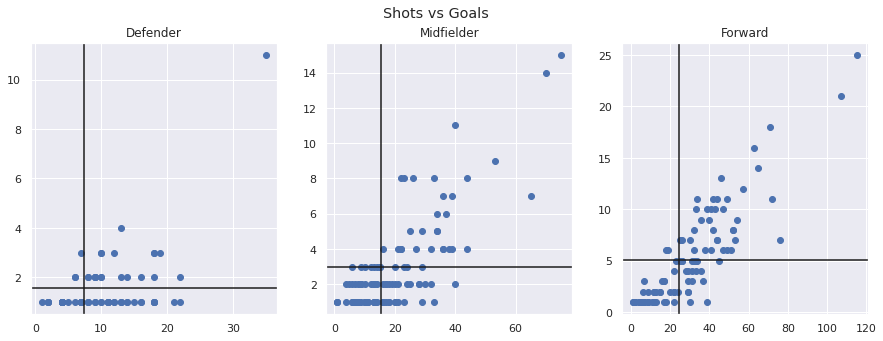

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15,5))

ax[0].scatter(x=defender.shots_total, y=defender.goals)
ax[0].set_title('Defender')
ax[0].axvline(defender.shots_total.mean(), c='k')
ax[0].axhline(defender.goals.mean(), c='k')

ax[1].scatter(x=md.shots_total, y=md.goals)
ax[1].set_title('Midfielder')
ax[1].axvline(md.shots_total.mean(), c='k')
ax[1].axhline(md.goals.mean(), c='k')

ax[2].scatter(x=fw.shots_total, y=fw.goals)
ax[2].set_title('Forward')
ax[2].axvline(fw.shots_total.mean(), c='k')
ax[2].axhline(fw.goals.mean(), c='k')

fig.suptitle('Shots vs Goals')
plt.show()

Como podemos ver, es exactamente lo mismo, solo sustituimos plt por ax, en este caso ax[0], porque estamos añadiendo el gráfico a la primera columna. 

La única diferencia es, que el título  y el nombre de  los ejes, ya no se hace con .title(), .xlabel() e .ylabel(), si no con .set_title(), .set_xlable() y .set_ylabel(). Este sería el resultado final al añadir las tres posiciones.


Ahora se puede entender mejor a lo que me refería con filas y columnas. Tenemos una fila con 3 columnas, en cada columna, va cada uno de los gráficos. Por eso necesitábamos pasar los índices de cada columna a la variable ax. Ahora tenemos el resultado de la comparación, de los disparos con los goles, pero con un gráfico para cada posición.

## 3.6.2. Múltiples gráficos con seaborn
Si queremos añadir algún gráfico de seaborn una vez utilizamos plt.subplots(), ya no añadiremos el gráfico a través de ax[0]. si no que los gráficos de seaborn tiene el parámetro ax, por tanto si el primer gráfico queremos que sea uno de seaborn parámetro ax quedará de la siguiente manera, ax=ax[0]. 

Vamos a graficar diferentes gráficos en una misma imagen. Un box plot, scatter plot y un pie chart.


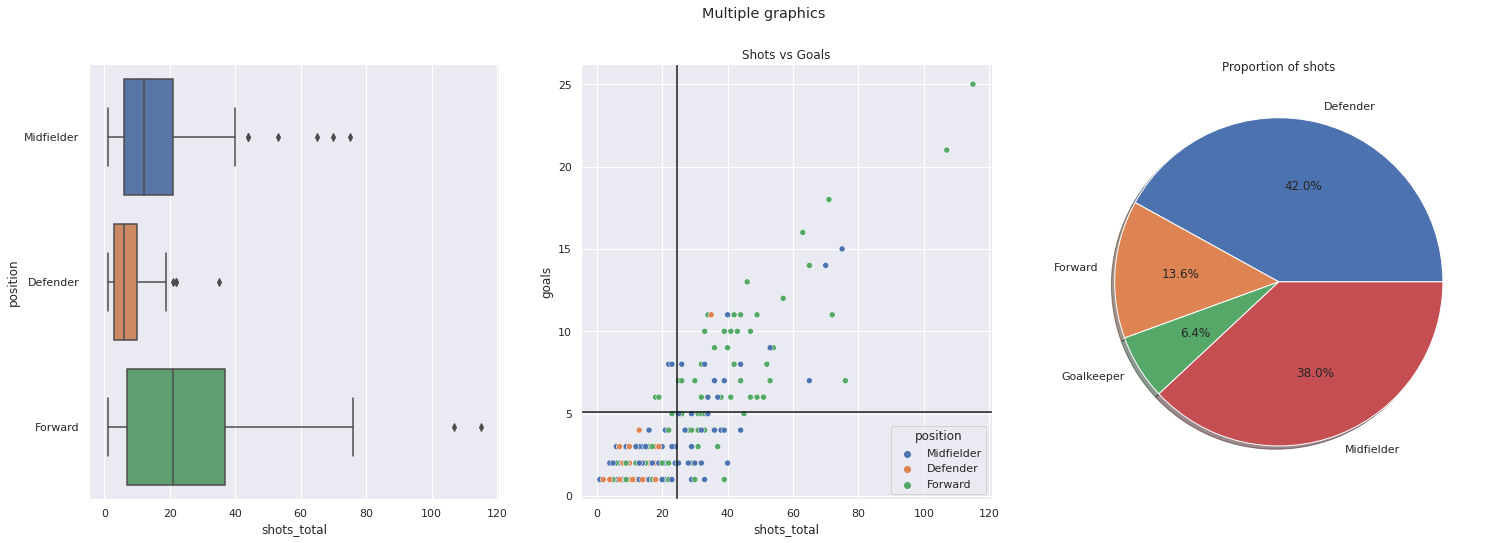

In [31]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(25,8))

# Añadir un box plot
sns.boxplot(data=df[df.position != 'Goalkeeper'], x='shots_total', y='position', ax=ax[0])

# Añadir un scatter plot
sns.scatterplot(data=df[df.position != 'Goalkeeper'], x='shots_total', y='goals', hue='position', ax=ax[1])
ax[1].set_title('Shots vs Goals')
ax[1].axvline(df[df.position=='Forward'].shots_total.mean(), c='k')
ax[1].axhline(df[df.position=='Forward'].goals.mean(), c='k')

# Añadir un pie chart
ax[2].pie(x=group.values, labels=group.index, autopct='%1.1f%%', shadow=True)
ax[2].set_title('Proportion of shots')

fig.suptitle('Multiple graphics')
plt.show()

En este caso solo hemos utilizado una fila, si quisiéramos añadir más filas y columnas de gráficos a la imagen, pasaremos de utilizar ax[0] a ax[0,0] para especificar el gráfico de la primera fila, primera columna y ax[1,0] para especificar segunda fila, primera columna. Veamos un ejemplo de cómo graficamos 4 gráficos con dos filas y dos columnas.


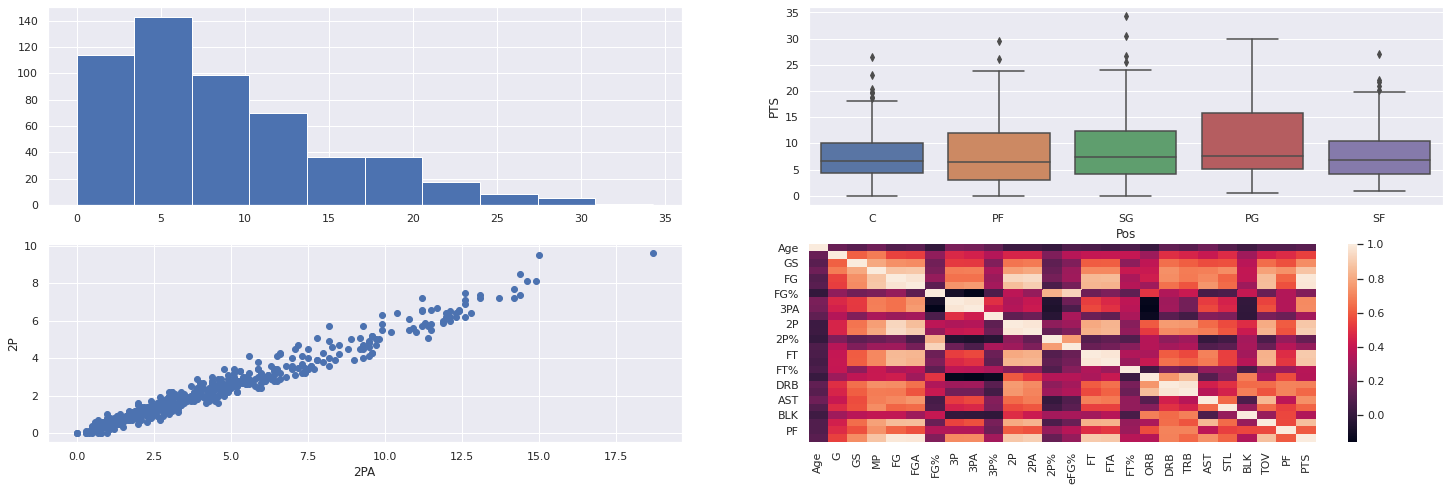

In [32]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(25,8))

# Histograma
ax[0,0].hist(nba.PTS)

# Scatter plot
ax[1,0].scatter(nba['2PA'], nba['2P'])
ax[1,0].set_xlabel('2PA')
ax[1,0].set_ylabel('2P')

# Box plot
sns.boxplot(data=nba, x='Pos', y='PTS', ax=ax[0,1])

# Heat map
sns.heatmap(nba.corr(), ax=ax[1,1])

# 3.7. Gráficos en 3D
Después de graficar dos columnas numéricas, si quisiéramos graficar más, nosotros como humanos solo podemos interpretar visualmente hasta 3 columnas numéricas con un gráfico en 3D. 

Con plotly vamos hacer un gráfico en 3D de una manera muy sencilla, con px.scatter_3d(). Recuerda que en la teoría sólo se podrán mostrar imágenes ya que el gráfico es interactivo y se puede mover para poder apreciar el 3D, te recomiendo que vayas al notebook para poder apreciarlo.

Vamos a realizar un top 25 de los jugadores de la NBA que más puntos meten, después vamos a graficar los puntos, los tiros de dos y los tipres. De esta manera vamos a poder visualizar en un gráfico en 3D como son los jugadores que más anotan, si tiran más de 2 o de 3

Antes graficando 2 variables teníamos el eje x e y, ahora pasamos a tener el eje (x, y, z). 

- x: Será el ancho del gráfico.
- y: Será el alto del gráfico.
- z: Será la profundidad del gráfico. 


In [ ]:
top_25 = nba.sort_values('PTS', ascending=False).head(25)
px.scatter_3d(top_25, x='PTS', y='3P', z='2P', text='Player', width=1300, height=900)

Podemos ver como Westbrook y Antetokounmpo son jugadores que tiran más de 2 que de 3. En cambio Harden centra su anotación desde el triple. Gracias al gráfico en 3D podemos evaluar el patrón de anotación de los jugadores de la NBA.
